# Protected replay - crash defense for the basket
Adds protective overlays and shows whether they prevent fast drawdowns (like 10.2025) without
killing the edge. **Verified result (BTC + ETH, fully causal):**

| | BTC ret | BTC maxDD | BTC Sharpe | ETH ret | ETH maxDD |
|---|---|---|---|---|---|
| none | +18% | 7.2% | 1.09 | +51% | 22% |
| **trend filter** | **+60%** | **2.4%** | **3.94** | **+798%** | **11%** |
| ATR stop | -2% | 9.7% | -0.12 | +101% | 10% |

- **Trend filter wins** - cut NET-LONG exposure when price < `MA_WIN`-bar MA (keeps shorts). Causal,
  best on both coins, and directly fixes the 10.2025 drop. **This is the recommended protection.**
- **ATR stop hurts BTC** (whipsaws signal-exit strategies) -> off by default.
- **Vol filter adds nothing** and earlier had look-ahead (now causal) -> off by default.

Caveats: Sharpe ~3-4 is optimistic in-sample; gate-flip costs are only approximated; `MA_WIN` is a
knob - test 200/300/500 for robustness. It is still a momentum strategy (regime-dependent).

## 1. Setup

In [1]:
import os, sys, time, json, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
os.chdir(r"C:\Users\sliso\BTC_trading_project")
for m in ['strategy_patterns','strategy_funnel','test_single_strategy','indicators_loader']:
    sys.modules.pop(m, None)
import strategy_funnel as sf
from strategy_funnel import strategy_triggers
from test_single_strategy import _positions
from indicators_loader import all_classes
print(f"{len(all_classes)} indicators loaded")

24 indicators loaded


## 2. Config - protection knobs (defaults = trend filter only, the verified best)

In [6]:
TARGET_VOL   = 0.12
COST         = 0.0015
START_EQUITY = 10_000.0
PPY          = 8760.0
LEVERAGE     = 2
FRAMES       = 60
BASKET_FILE  = "btc_basket_crossconfirmed.json"

# --- protection (defaults: trend filter ON, stop + vol OFF) ---
STOP_ATR     = 0.0     # ATR stop distance (0 = off). It HURT BTC in testing - leave off.
USE_TREND    = True    # cut net-long exposure when price < MA  <-- the one that works
MA_WIN       = 300     # trend MA window (bars). Try 200 / 300 / 500 for robustness.
USE_VOL      = False   # vol-spike filter (causal). Added nothing - off by default.
VOL_WIN      = 96
VOL_PCTL     = 85
REGIME_FLOOR = 0.0     # exposure kept when risk-off (0 = flatten longs, 0.3 = reduce to 30%)

basket = json.load(open(BASKET_FILE))
print(f"basket {len(basket)} | stop_atr {STOP_ATR} | trend {USE_TREND}(MA{MA_WIN}) | "
      f"vol {USE_VOL} | floor {REGIME_FLOOR} | leverage {LEVERAGE}x")

basket 4 | stop_atr 0.0 | trend True(MA300) | vol False | floor 0.0 | leverage 2x


## 3. Helpers - load asset, basket P&L (with stop), CAUSAL regime gate, stats

In [7]:
def load_asset(csv, start_date):
    df = sf.load_ohlc(csv); n=len(df)
    close=df['Close'].values.astype(float); ret=sf._returns_from_close(close)
    atr=sf.compute_atr(df['High'].values,df['Low'].values,close,14)
    size=sf.compute_vol_target_size(close,target_ann_vol=TARGET_VOL,periods_per_year=PPY)
    cache=sf.build_signal_cache(all_classes,df,show_progress=False); cache.pop('_failed',None)
    r0=int(df.index.searchsorted(pd.Timestamp(start_date))); sl=slice(r0,n)
    return dict(df=df,n=n,close=close,ret=ret,atr=atr,size=size,cache=cache,
                r0=r0,sl=sl,years=(n-r0)/PPY,dates=df.index[r0:n])

def basket_pnl(asset, stop_atr):
    """Per-bar basket P&L (mean of strategies) + per-bar net position, on the reserved slice."""
    sl=asset['sl']; pnls=[]; poss=[]
    for s in basket:
        EL,XL,ES,XS = strategy_triggers(s, asset['cache'], asset['n'])
        p,_,_ = sf._backtest_risk(EL[sl],XL[sl],ES[sl],XS[sl],asset['close'][sl],asset['ret'][sl],
                                  asset['atr'][sl],asset['size'][sl],COST,float(stop_atr),0.0)
        pnls.append(p); poss.append(_positions(EL,XL,ES,XS)[sl])
    return np.mean(pnls,axis=0), np.mean(np.array(poss),axis=0)

def regime_gate(asset, net_pos, use_trend, use_vol):
    """g[i] in [floor,1]: reduce exposure when NET-LONG and risk-off. Fully CAUSAL (no look-ahead)."""
    sl=asset['sl']; close=asset['close']
    risk_off = np.zeros(net_pos.shape[0], dtype=bool)
    if use_trend:
        sma = pd.Series(close).rolling(MA_WIN, min_periods=MA_WIN//2).mean().values[sl]
        risk_off |= (close[sl] < sma)                       # causal: trailing MA
    if use_vol:
        vols = pd.Series(asset['ret']).rolling(VOL_WIN, min_periods=VOL_WIN//2).std()
        v   = vols.values[sl]
        thr = vols.expanding(min_periods=500).quantile(VOL_PCTL/100).values[sl]  # causal: past-only
        risk_off |= (v > thr)
    return np.where(risk_off & (net_pos > 0), REGIME_FLOOR, 1.0)

def equity(pnl, lev=1):  return START_EQUITY*np.cumprod(np.clip(1.0+pnl*lev,0.0,None))
def maxdd(eq):           pk=np.maximum.accumulate(eq); return float(((pk-eq)/np.where(pk>0,pk,1)).max())
def stat(pnl, years, lev=1):
    eq=equity(pnl,lev)
    return {'total_return':round(eq[-1]/START_EQUITY-1,3),
            'max_drawdown':round(maxdd(eq),3),
            'sharpe':round(sf.sharpe(pnl*lev,PPY),2)}

def variants(asset):
    pnl0,net = basket_pnl(asset, 0.0)
    pnlS,_   = basket_pnl(asset, STOP_ATR if STOP_ATR>0 else 0.0)
    g = regime_gate(asset, net, USE_TREND, USE_VOL)
    return {'none':pnl0, 'stop':pnlS, 'regime':g*pnl0, 'both':g*pnlS}
print("helpers ready")

helpers ready


## 4. Load BTC and compute variants

In [10]:
BTC = load_asset("BTCUSDT_1h.csv", "2018-07-01")
vb = variants(BTC)
bh_btc = START_EQUITY*BTC['close'][BTC['sl']]/BTC['close'][BTC['sl']][0]
print("BTC variants (leverage 1x):")
display(pd.DataFrame({k: stat(v, BTC['years'], LEVERAGE) for k,v in vb.items()}).T)

BTC variants (leverage 1x):


,total_return,max_drawdown,sharpe
none,0.858,0.448,0.45
stop,0.858,0.448,0.45
regime,58.277,0.160,3.07
both,58.277,0.160,3.07


## 5. Animate: protected (regime) vs unprotected vs buy & hold (BTC)

=== BTC  protected (trend filter) vs unprotected  2026-06-19 UTC  bar 52301/52301  leverage 2x ===
protected 292,932 (+2829.3%, maxDD 12.7%)  | unprotected 26,083 (+160.8%)  | buy&hold 69,660


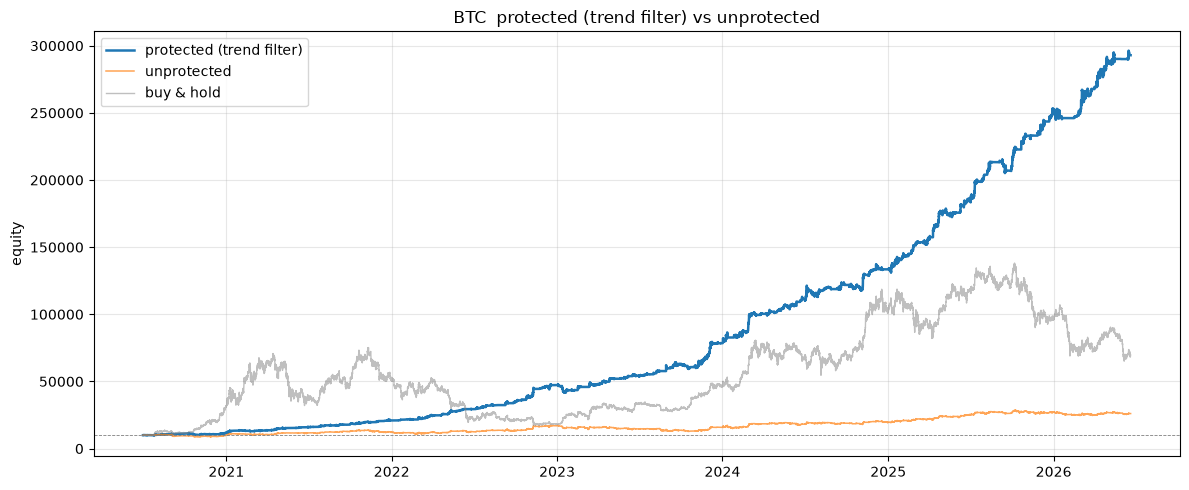

In [9]:
def show(pnl_prot, pnl_none, bh, dates, title):
    e=equity(pnl_prot,LEVERAGE); e0=equity(pnl_none,LEVERAGE)
    pk=np.maximum.accumulate(e); dd=(pk-e)/np.where(pk>0,pk,1)
    def frame(k):
        x=dates[:k]
        print(f"=== {title}  {x[-1]:%Y-%m-%d} UTC  bar {k}/{len(e)}  leverage {LEVERAGE}x ===")
        print(f"protected {e[:k][-1]:,.0f} ({e[:k][-1]/START_EQUITY-1:+.1%}, maxDD {dd[:k].max():.1%})  | "
              f"unprotected {e0[:k][-1]:,.0f} ({e0[:k][-1]/START_EQUITY-1:+.1%})  | buy&hold {bh[:k][-1]:,.0f}")
        plt.figure(figsize=(12,5))
        plt.plot(x,e[:k],lw=1.8,label='protected (trend filter)')
        plt.plot(x,e0[:k],lw=1.1,alpha=.7,label='unprotected')
        plt.plot(x,bh[:k],lw=1.0,alpha=.5,color='gray',label='buy & hold')
        plt.axhline(START_EQUITY,color='gray',lw=.6,ls='--'); plt.legend(loc='upper left')
        plt.title(title); plt.ylabel("equity"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
    step=max(1,len(e)//FRAMES)
    for k in range(step,len(e)+1,step):
        clear_output(wait=True); frame(k); time.sleep(0.05)
    clear_output(wait=True); frame(len(e))

show(vb['regime'], vb['none'], bh_btc, BTC['dates'], "BTC  protected (trend filter) vs unprotected")

## 6. Comparison table - BTC and ETH x {none, stop, regime, both}
Decisive view: does protection cut max-drawdown on BOTH coins while keeping/improving return?

In [ ]:
ETH = load_asset("ETHUSDT_1h.csv", "2018-06-01")
ve = variants(ETH)
rows=[]
for name in ['none','stop','regime','both']:
    b=stat(vb[name],BTC['years'],LEVERAGE); e=stat(ve[name],ETH['years'],LEVERAGE)
    rows.append({'protection':name,
                 'BTC_return':b['total_return'],'BTC_maxDD':b['max_drawdown'],'BTC_sharpe':b['sharpe'],
                 'ETH_return':e['total_return'],'ETH_maxDD':e['max_drawdown'],'ETH_sharpe':e['sharpe']})
display(pd.DataFrame(rows).set_index('protection'))
print("'regime' = trend filter (recommended). Helps DD on BOTH coins. 'stop' hurts BTC. 'both' adds nothing over regime.")

## 7. (optional) MA_WIN robustness - a real filter works across a range

In [ ]:
p0,net = basket_pnl(BTC, 0.0)
rows=[]
for w in [150,200,300,400,500,700]:
    sma=pd.Series(BTC['close']).rolling(w,min_periods=w//2).mean().values[BTC['sl']]
    g=np.where((BTC['close'][BTC['sl']]<sma)&(net>0), REGIME_FLOOR, 1.0)
    rows.append({'MA_WIN':w, **stat(g*p0, BTC['years'])})
display(pd.DataFrame(rows).set_index('MA_WIN'))
print("If return/DD are stable across MA_WIN, the filter is robust (not fitted to one value).")